- Persistence (lag-h) and climatological mean baselines, evaluated in log space (`log1p(flow)`)
- Horizons: t+1, t+3, t+7, t+10, t+14; metric: median NSE across 146 UKBN2 stations
- Outputs: `results/naive_multihorizon_results.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

In [2]:
train_data = pd.read_feather('../checkpoints/train_data.feather')
val_data   = pd.read_feather('../checkpoints/val_data.feather')
test_data  = pd.read_feather('../checkpoints/test_data.feather')

train_data['date'] = pd.to_datetime(train_data['date'])
val_data['date']   = pd.to_datetime(val_data['date'])
test_data['date']  = pd.to_datetime(test_data['date'])

print(f"train : {train_data.shape}  ({train_data['station_id'].nunique()} stations, "
      f"{train_data['date'].min().date()} to {train_data['date'].max().date()})")
print(f"val   : {val_data.shape}  ({val_data['station_id'].nunique()} stations, "
      f"{val_data['date'].min().date()} to {val_data['date'].max().date()})")
print(f"test  : {test_data.shape}  ({test_data['station_id'].nunique()} stations, "
      f"{test_data['date'].min().date()} to {test_data['date'].max().date()})")
print(f"\nflow NaN fraction:  train={train_data['flow'].isna().mean():.3f}, "
      f"val={val_data['flow'].isna().mean():.3f}, test={test_data['flow'].isna().mean():.3f}")

train : (12229250, 42)  (1396 stations, 1994-01-01 to 2017-12-31)
val   : (1019080, 42)  (1396 stations, 2018-01-01 to 2019-12-31)
test  : (2368865, 42)  (1396 stations, 2020-01-01 to 2024-09-30)



flow NaN fraction:  train=0.098, val=0.116, test=0.110


In [3]:
import pandas as pd
benchmark = pd.read_csv('../data/benchmark.csv')
benchmark_ids = set(benchmark['Station'].astype(int).tolist())

train_data = train_data[train_data['station_id'].isin(benchmark_ids)].reset_index(drop=True)
val_data   = val_data[val_data['station_id'].isin(benchmark_ids)].reset_index(drop=True)
test_data  = test_data[test_data['station_id'].isin(benchmark_ids)].reset_index(drop=True)

print(f'After benchmark filter:')
print(f'  train : {train_data.shape}  ({train_data["station_id"].nunique()} stations)')
print(f'  val   : {val_data.shape}  ({val_data["station_id"].nunique()} stations)')
print(f'  test  : {test_data.shape}  ({test_data["station_id"].nunique()} stations)')

After benchmark filter:
  train : (1279836, 42)  (146 stations)
  val   : (106580, 42)  (146 stations)
  test  : (251712, 42)  (146 stations)


In [4]:
HORIZONS = [1, 3, 7, 10, 14]


def nse(y_true, y_pred):
    """Nash-Sutcliffe Efficiency: 1 = perfect, 0 = mean baseline, <0 = worse."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

- Persistence exploits AR(1) autocorrelation and sets the short-horizon ceiling; climatological mean (NSE=0 by construction on training) sets the floor
- The crossover between t+3 and t+7 marks the limit of useful autoregressive memory in daily flow

In [5]:
def evaluate_persistence(data, horizons=HORIZONS):
    """
    Persistence baseline: flow_hat(t+h) = flow(t).
    
    Evaluated in log space: NSE/RMSE computed on log1p(flow).
    """
    results = []
    stations = data['station_id'].unique()
    
    for h in horizons:
        for i, sid in enumerate(stations):
            if (i + 1) % 500 == 0:
                print(f'  t+{h}: station {i+1}/{len(stations)}...')
            
            g = data.loc[data['station_id'] == sid].sort_values('date')
            flow = g['flow'].values
            
            if len(flow) <= h:
                results.append({
                    'station_id': sid, 'horizon': f't+{h}',
                    'test_nse': np.nan, 'test_rmse': np.nan,
                })
                continue
            
            y_pred = flow[:-h]   # flow(t)
            y_true = flow[h:]    # flow(t+h)
            
            valid = ~(np.isnan(y_true) | np.isnan(y_pred))
            y_true, y_pred = y_true[valid], y_pred[valid]
            
            if len(y_true) < 10:
                results.append({
                    'station_id': sid, 'horizon': f't+{h}',
                    'test_nse': np.nan, 'test_rmse': np.nan,
                })
                continue
            
            log_true = np.log1p(y_true)
            log_pred = np.log1p(y_pred)
            
            results.append({
                'station_id': sid, 'horizon': f't+{h}',
                'test_nse': nse(log_true, log_pred),
                'test_rmse': rmse(log_true, log_pred),
            })
    
    return pd.DataFrame(results)

In [6]:
print('Evaluating persistence on validation set (log space)...')
persist_val = evaluate_persistence(val_data)
persist_val = persist_val.rename(columns={'test_nse': 'val_nse', 'test_rmse': 'val_rmse'})

print('\nEvaluating persistence on test set (log space)...')
persist_test = evaluate_persistence(test_data)

persist_results = persist_test.merge(
    persist_val[['station_id', 'horizon', 'val_nse']],
    on=['station_id', 'horizon'],
    how='left'
)

train_n = (train_data.groupby('station_id')['flow']
           .apply(lambda x: x.notna().sum())
           .reset_index(name='n_train'))
persist_results = persist_results.merge(train_n, on='station_id', how='left')
persist_results['model'] = 'persistence'

print('\nPersistence Baseline — log-NSE (Test Set)')
for h in HORIZONS:
    vals = persist_results.loc[persist_results['horizon'] == f't+{h}', 'test_nse'].dropna()
    print(f'  t+{h:>2}: median log-NSE = {vals.median():.4f}  '
          f'(n={len(vals)}, NaN={persist_results.loc[persist_results["horizon"]==f"t+{h}", "test_nse"].isna().sum()})')

Evaluating persistence on validation set (log space)...



Evaluating persistence on test set (log space)...



Persistence Baseline — log-NSE (Test Set)
  t+ 1: median log-NSE = 0.7684  (n=143, NaN=3)
  t+ 3: median log-NSE = 0.4341  (n=143, NaN=3)
  t+ 7: median log-NSE = 0.1720  (n=143, NaN=3)
  t+10: median log-NSE = 0.0124  (n=143, NaN=3)
  t+14: median log-NSE = -0.0864  (n=143, NaN=3)


In [7]:
def compute_monthly_climatology(train_data):
    """
    Mean log1p(flow) per station per calendar month from training data.
    Climatological prediction is in log space.
    """
    valid = train_data.dropna(subset=['flow']).copy()
    valid['month'] = valid['date'].dt.month
    valid['log_flow'] = np.log1p(valid['flow'])
    return (
        valid
        .groupby(['station_id', 'month'])['log_flow']
        .mean()
        .reset_index()
        .rename(columns={'log_flow': 'clim_mean_log'})
    )


def evaluate_climatology(data, clim, horizons=HORIZONS):
    """
    Climatological mean baseline: for each day, predict the training-set
    mean log1p(flow) for that station and the TARGET date's calendar month.
    
    Evaluated in log space: NSE/RMSE computed on log1p(flow).
    """
    results = []
    stations = data['station_id'].unique()
    
    for h in horizons:
        for i, sid in enumerate(stations):
            if (i + 1) % 500 == 0:
                print(f'  t+{h}: station {i+1}/{len(stations)}...')
            
            g = data.loc[data['station_id'] == sid].sort_values('date').copy()
            
            g['log_target'] = np.log1p(g['flow'].shift(-h))
            g['target_month'] = (g['date'] + pd.Timedelta(days=h)).dt.month
            
            sid_clim = clim.loc[clim['station_id'] == sid, ['month', 'clim_mean_log']]
            g = g.merge(sid_clim, left_on='target_month', right_on='month', how='left')
            
            valid = g['log_target'].notna() & g['clim_mean_log'].notna()
            y_true = g.loc[valid, 'log_target'].values
            y_pred = g.loc[valid, 'clim_mean_log'].values
            
            if len(y_true) < 10:
                results.append({
                    'station_id': sid, 'horizon': f't+{h}',
                    'test_nse': np.nan, 'test_rmse': np.nan,
                })
                continue
            
            results.append({
                'station_id': sid, 'horizon': f't+{h}',
                'test_nse': nse(y_true, y_pred),
                'test_rmse': rmse(y_true, y_pred),
            })
    
    return pd.DataFrame(results)

In [8]:
clim = compute_monthly_climatology(train_data)
print(f'Climatology (log space): {len(clim)} station-month entries '
      f'({clim["station_id"].nunique()} stations)')

print('\nEvaluating climatological mean on validation set (log space)...')
clim_val = evaluate_climatology(val_data, clim)
clim_val = clim_val.rename(columns={'test_nse': 'val_nse', 'test_rmse': 'val_rmse'})

print('\nEvaluating climatological mean on test set (log space)...')
clim_test = evaluate_climatology(test_data, clim)

clim_results = clim_test.merge(
    clim_val[['station_id', 'horizon', 'val_nse']],
    on=['station_id', 'horizon'],
    how='left'
)
clim_results = clim_results.merge(train_n, on='station_id', how='left')
clim_results['model'] = 'climatology'

print('\nClimatological Mean Baseline — log-NSE (Test Set)')
for h in HORIZONS:
    vals = clim_results.loc[clim_results['horizon'] == f't+{h}', 'test_nse'].dropna()
    print(f'  t+{h:>2}: median log-NSE = {vals.median():.4f}  '
          f'(n={len(vals)}, NaN={clim_results.loc[clim_results["horizon"]==f"t+{h}", "test_nse"].isna().sum()})')

Climatology (log space): 1752 station-month entries (146 stations)

Evaluating climatological mean on validation set (log space)...



Evaluating climatological mean on test set (log space)...



Climatological Mean Baseline — log-NSE (Test Set)
  t+ 1: median log-NSE = 0.3397  (n=143, NaN=3)
  t+ 3: median log-NSE = 0.3402  (n=143, NaN=3)
  t+ 7: median log-NSE = 0.3404  (n=143, NaN=3)
  t+10: median log-NSE = 0.3403  (n=143, NaN=3)
  t+14: median log-NSE = 0.3387  (n=143, NaN=3)


In [9]:
all_naive = pd.concat([persist_results, clim_results], ignore_index=True)

print('=' * 60)
print('Naive Baselines — Median Test log-NSE by Horizon')
print('=' * 60)

for model in ['persistence', 'climatology']:
    print(f'\n  {model.upper()}')
    for h in HORIZONS:
        vals = all_naive.loc[
            (all_naive['model'] == model) & (all_naive['horizon'] == f't+{h}'),
            'test_nse'
        ].dropna()
        print(f'    t+{h:>2}: median log-NSE = {vals.median():.4f}  '
              f'mean log-NSE = {vals.mean():.4f}  (n={len(vals)})')

print('\n' + '=' * 60)
print('Persistence vs Climatology — Median Test log-NSE')
print('=' * 60)
for h in HORIZONS:
    p = persist_results.loc[persist_results['horizon'] == f't+{h}', 'test_nse'].dropna().median()
    c = clim_results.loc[clim_results['horizon'] == f't+{h}', 'test_nse'].dropna().median()
    better = 'persistence' if p > c else 'climatology'
    print(f'  t+{h:>2}: persistence={p:.4f}  climatology={c:.4f}  ({better} wins)')

Naive Baselines — Median Test log-NSE by Horizon

  PERSISTENCE
    t+ 1: median log-NSE = 0.7684  mean log-NSE = 0.7605  (n=143)
    t+ 3: median log-NSE = 0.4341  mean log-NSE = 0.4636  (n=143)
    t+ 7: median log-NSE = 0.1720  mean log-NSE = 0.2189  (n=143)
    t+10: median log-NSE = 0.0124  mean log-NSE = 0.0801  (n=143)
    t+14: median log-NSE = -0.0864  mean log-NSE = -0.0151  (n=143)

  CLIMATOLOGY
    t+ 1: median log-NSE = 0.3397  mean log-NSE = 0.3343  (n=143)
    t+ 3: median log-NSE = 0.3402  mean log-NSE = 0.3343  (n=143)
    t+ 7: median log-NSE = 0.3404  mean log-NSE = 0.3345  (n=143)
    t+10: median log-NSE = 0.3403  mean log-NSE = 0.3340  (n=143)
    t+14: median log-NSE = 0.3387  mean log-NSE = 0.3328  (n=143)

Persistence vs Climatology — Median Test log-NSE
  t+ 1: persistence=0.7684  climatology=0.3397  (persistence wins)
  t+ 3: persistence=0.4341  climatology=0.3402  (persistence wins)
  t+ 7: persistence=0.1720  climatology=0.3404  (climatology wins)
  t+10: 

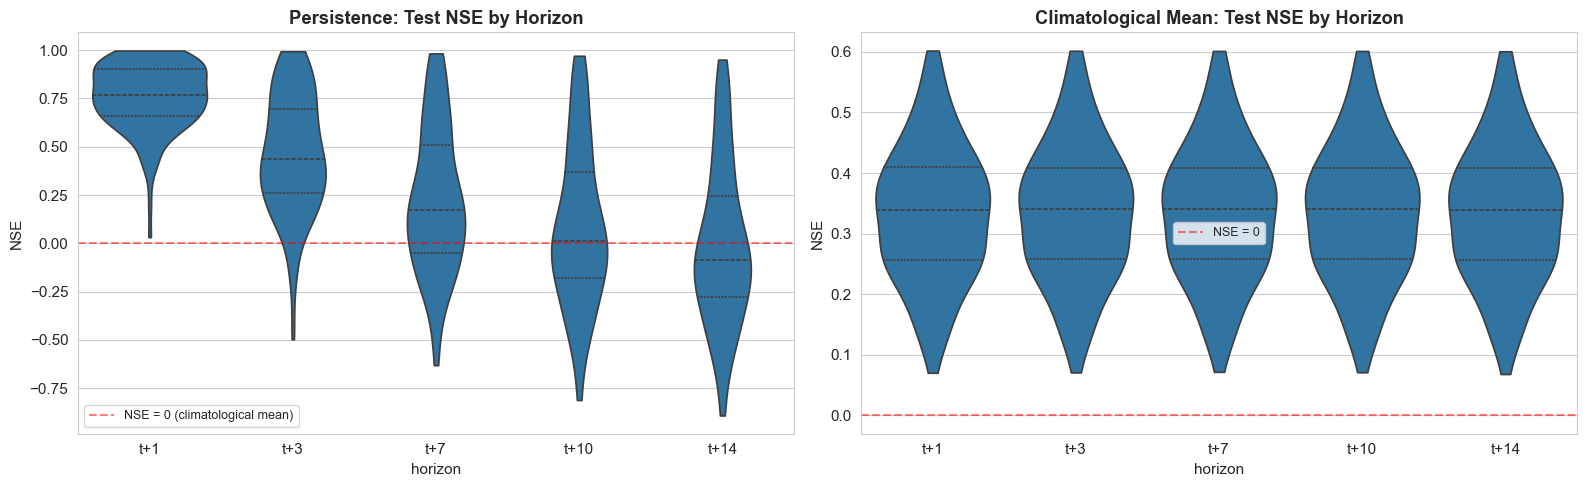

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order = [f't+{h}' for h in HORIZONS]

sns.violinplot(
    data=persist_results, x='horizon', y='test_nse',
    order=order, ax=axes[0], inner='quartile', cut=0
)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5, label='NSE = 0 (climatological mean)')
axes[0].set_title('Persistence: Test NSE by Horizon', fontweight='bold')
axes[0].set_ylabel('NSE')
axes[0].legend(fontsize=9)

sns.violinplot(
    data=clim_results, x='horizon', y='test_nse',
    order=order, ax=axes[1], inner='quartile', cut=0
)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5, label='NSE = 0')
axes[1].set_title('Climatological Mean: Test NSE by Horizon', fontweight='bold')
axes[1].set_ylabel('NSE')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

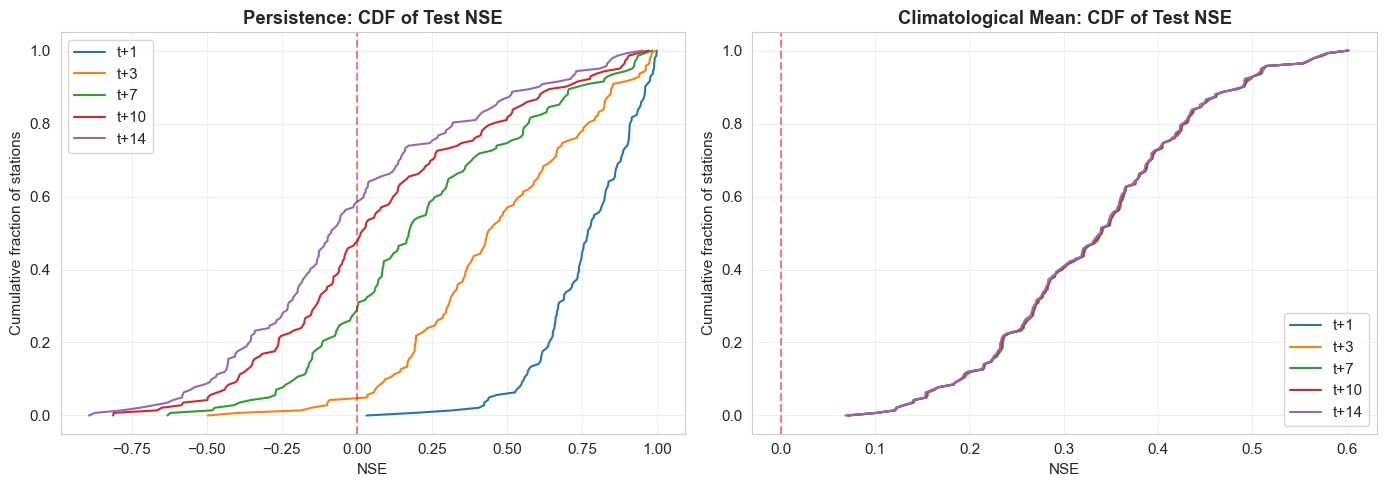

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for h in HORIZONS:
    vals = persist_results.loc[
        persist_results['horizon'] == f't+{h}', 'test_nse'
    ].dropna().sort_values()
    axes[0].plot(vals.values, np.linspace(0, 1, len(vals)), label=f't+{h}')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('NSE')
axes[0].set_ylabel('Cumulative fraction of stations')
axes[0].set_title('Persistence: CDF of Test NSE', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

for h in HORIZONS:
    vals = clim_results.loc[
        clim_results['horizon'] == f't+{h}', 'test_nse'
    ].dropna().sort_values()
    axes[1].plot(vals.values, np.linspace(0, 1, len(vals)), label=f't+{h}')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('NSE')
axes[1].set_ylabel('Cumulative fraction of stations')
axes[1].set_title('Climatological Mean: CDF of Test NSE', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
print('Fraction of stations below key NSE thresholds (test set):')
print()
for model_name, df in [('PERSISTENCE', persist_results), ('CLIMATOLOGY', clim_results)]:
    print(f'  {model_name}')
    for h in HORIZONS:
        vals = df.loc[df['horizon'] == f't+{h}', 'test_nse'].dropna()
        n = len(vals)
        print(f'    t+{h:>2}: NSE<0 = {(vals<0).mean():.1%},  '
              f'NSE<0.3 = {(vals<0.3).mean():.1%},  '
              f'NSE>=0.5 = {(vals>=0.5).mean():.1%}  (n={n})')
    print()

Fraction of stations below key NSE thresholds (test set):

  PERSISTENCE
    t+ 1: NSE<0 = 0.0%,  NSE<0.3 = 1.4%,  NSE>=0.5 = 93.7%  (n=143)
    t+ 3: NSE<0 = 4.9%,  NSE<0.3 = 29.4%,  NSE>=0.5 = 43.4%  (n=143)
    t+ 7: NSE<0 = 28.7%,  NSE<0.3 = 63.6%,  NSE>=0.5 = 25.2%  (n=143)
    t+10: NSE<0 = 47.6%,  NSE<0.3 = 72.7%,  NSE>=0.5 = 18.2%  (n=143)
    t+14: NSE<0 = 58.7%,  NSE<0.3 = 78.3%,  NSE>=0.5 = 13.3%  (n=143)

  CLIMATOLOGY
    t+ 1: NSE<0 = 0.0%,  NSE<0.3 = 40.6%,  NSE>=0.5 = 7.7%  (n=143)
    t+ 3: NSE<0 = 0.0%,  NSE<0.3 = 40.6%,  NSE>=0.5 = 7.7%  (n=143)
    t+ 7: NSE<0 = 0.0%,  NSE<0.3 = 40.6%,  NSE>=0.5 = 7.7%  (n=143)
    t+10: NSE<0 = 0.0%,  NSE<0.3 = 40.6%,  NSE>=0.5 = 7.7%  (n=143)
    t+14: NSE<0 = 0.0%,  NSE<0.3 = 41.3%,  NSE>=0.5 = 7.7%  (n=143)



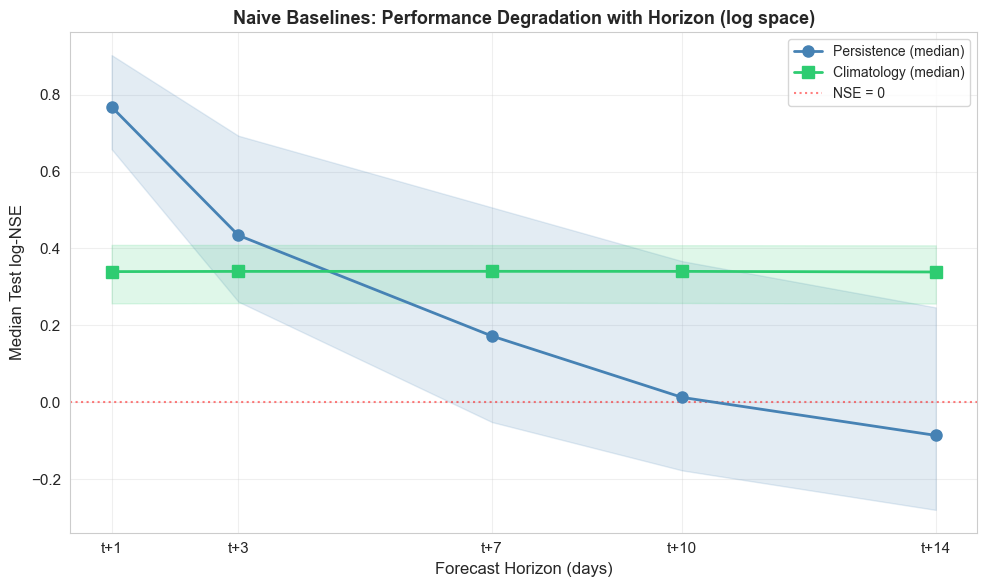

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

for model_name, df, color, marker in [
    ('Persistence', persist_results, 'steelblue', 'o'),
    ('Climatology', clim_results, '#2ecc71', 's'),
]:
    medians, q25s, q75s = [], [], []
    for h in HORIZONS:
        vals = df.loc[df['horizon'] == f't+{h}', 'test_nse'].dropna()
        medians.append(vals.median())
        q25s.append(vals.quantile(0.25))
        q75s.append(vals.quantile(0.75))

    ax.plot(HORIZONS, medians, f'{marker}-', color=color, linewidth=2,
            markersize=8, label=f'{model_name} (median)', zorder=3)
    ax.fill_between(HORIZONS, q25s, q75s, alpha=0.15, color=color)

ax.axhline(0, color='red', linestyle=':', alpha=0.5, label='NSE = 0')
ax.set_xlabel('Forecast Horizon (days)', fontsize=12)
ax.set_ylabel('Median Test log-NSE', fontsize=12)
ax.set_title('Naive Baselines: Performance Degradation with Horizon (log space)',
             fontweight='bold', fontsize=13)
ax.set_xticks(HORIZONS)
ax.set_xticklabels([f't+{h}' for h in HORIZONS])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()

os.makedirs('../figures-log', exist_ok=True)
fig.savefig('../figures-log/naive_violin.png', dpi=150, bbox_inches='tight')
plt.show()

- Persistence: median log-NSE 0.77 at t+1, degrades to -0.09 at t+14 (below NSE=0 for 59% of stations)
- Climatology: roughly constant ~0.34 across all horizons (no dynamic information used)
- Beyond the crossover (~t+5), models must rely on rainfall or seasonal patterns to beat the long-run mean

In [14]:
os.makedirs('results', exist_ok=True)

output = all_naive[['station_id', 'horizon', 'model', 'val_nse', 'test_nse', 'test_rmse', 'n_train']].copy()
output.to_csv('results/naive_multihorizon_results.csv', index=False)

print(f'Saved {len(output)} rows to results/naive_multihorizon_results.csv')
print(f'  Models: {output["model"].unique().tolist()}')
print(f'  Horizons: {output["horizon"].unique().tolist()}')
print(f'  Stations: {output["station_id"].nunique()}')

Saved 1460 rows to results/naive_multihorizon_results.csv
  Models: ['persistence', 'climatology']
  Horizons: ['t+1', 't+3', 't+7', 't+10', 't+14']
  Stations: 146
